In [10]:
import tensorflow as tf
import urllib.request
import zipfile

url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"
file_name = "horse-or-human.zip"
training_dir = 'horse-or-human/training'
urllib.request.urlretrieve(url,file_name)

zip_ref = zipfile.ZipFile(file_name, 'r')
zip_ref.extractall(training_dir)
zip_ref.close()

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1/255)
train_generator = train_datagen.flow_from_directory(
    training_dir,
    target_size=(300, 300),
    class_mode = 'binary'
    )

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
from tensorflow.keras.optimizers import RMSprop
model.compile(loss='binary_crossentropy', optimizer=RMSprop(learning_rate=0.001), metrics=['accuracy'])

validation_url = "https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip"
validation_file_name = "validation-horse-or-human.zip"
validation_dir = 'horse-or-human/validation/'
urllib.request.urlretrieve(validation_url, validation_file_name)

zip_ref = zipfile.ZipFile(validation_file_name, 'r')
zip_ref.extractall(validation_dir)
zip_ref.close()

validation_datagen = ImageDataGenerator(rescale=1/255)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(300, 300),
    class_mode='binary'
)
model.fit(train_generator,
          epochs=15,
          validation_data = validation_generator)

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - accuracy: 0.5370 - loss: 0.9463 - val_accuracy: 0.7148 - val_loss: 0.5415
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.8204 - loss: 0.5214 - val_accuracy: 0.6641 - val_loss: 1.7893
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.9429 - loss: 0.1201 - val_accuracy: 0.8906 - val_loss: 0.6893
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.9653 - loss: 0.0898 - val_accuracy: 0.8516 - val_loss: 1.4336
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.9779 - loss: 0.0605 - val_accuracy: 0.7891 - val_loss: 2.7224
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.9487 - loss: 0.9127 - val_accuracy: 0.7969 - val_loss: 1.9972
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9928 - loss: 0.0476 - val_accuracy: 0.7812 - val_loss: 1.8883
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.9866 - loss: 0.0350 - val_accuracy: 0.7891 - v

In [20]:
import sys

if 'google.colab' in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    sample_images = ['/content/' + fn for fn in uploaded.keys()]
    if len(uploaded) < 1:
        import gdown
        base_url = 'https://github.com/rickiepark/aiml4coders/raw/main/ch03/'
        for i in range(1, 4):
            gdown.download(base_url + 'hh_image_{}.jpg'.format(i))
        sample_images = ['/content/hh_image_{}.jpg'.format(i) for i in range(1,4)]
else:
    sample_images = ['hh_image_{}.jpg'.format(i) for i in range(1,4)]

Saving hh_image_3.jpg to hh_image_3 (2).jpg
Saving hh_image_2.jpg to hh_image_2 (2).jpg
Saving hh_image_1.jpg to hh_image_1 (3).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
모델 출력 :  0.0
/content/hh_image_3 (2).jpg는 말 입니다.
---------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
모델 출력 :  1.0
/content/hh_image_2 (2).jpg는 사람입니다
---------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
모델 출력 :  1.0
/content/hh_image_1 (3).jpg는 사람입니다
---------------------


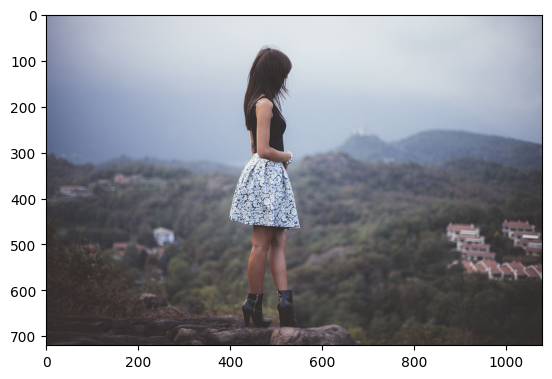

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.preprocessing import image

for fn in sample_images:
    plt.imshow(mpimg.imread(fn))
    plt.show

    img = tf.keras.utils.load_img(fn, target_size = (300, 300))
    x = tf.keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis = 0)

    classes = model.predict(x)

    print('모델 출력 : ', classes[0][0])
    if classes[0][0] > 0.5:
        print(fn + "는 사람입니다")
    else:
        print(fn + "는 말 입니다.")
    print('---------------------')